In [110]:
# libraries
import numpy as np
import pandas as pd
import random
import seaborn as sns
sns.set(style="ticks", color_codes=True)
from sklearn import neighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [111]:
#Columns/Features
D = ['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']
L = ['Sex']
C = 'Rings'
DL = D + L
DLC = D + [L] + [C]
DC = D + [C]


# #Loading Data set
abalone = pd.read_csv("abalone.csv", sep=',')


Data: shape=(4148, 7)


'describe'

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
count,4.148000e+03,4.148000e+03,4.148000e+03,4.148000e+03,4.148000e+03,4148.000000,4.148000e+03
mean,-7.365800e-16,5.995418e-17,7.194502e-17,5.652823e-17,-1.507419e-16,0.000000,-6.851907e-17
std,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,1.000121,1.000121e+00
min,-3.329521e+00,-3.133967e+00,-2.661584e+00,-1.677972e+00,-1.615009e+00,-1.663236,-1.698569e+00
25%,-6.452371e-01,-6.104144e-01,-6.608138e-01,-7.910098e-01,-7.840208e-01,-0.798213,-7.875661e-01
50%,1.643087e-01,1.621018e-01,6.109714e-03,-6.026803e-02,-1.051537e-01,-0.094232,-3.397615e-02
75%,7.608161e-01,7.286136e-01,6.730333e-01,6.625086e-01,6.469356e-01,0.661512,6.508589e-01
max,2.337300e+00,2.273646e+00,2.673804e+00,4.098074e+00,5.119171e+00,4.235483,5.538790e+00


'skew:'

Length           -0.582801
Diameter         -0.559487
Height           -0.184860
Whole weight      0.525137
Shucked weight    0.710195
Viscera weight    0.570953
Shell weight      0.622625
dtype: float64

...

'variance'

Length            1.000121
Diameter          1.000121
Height            1.000121
Whole weight      1.000121
Shucked weight    1.000121
Viscera weight    1.000121
Shell weight      1.000121
dtype: float64

'range:'

Length            5.666821
Diameter          5.407613
Height            5.335388
Whole weight      5.776046
Shucked weight    6.734179
Viscera weight    5.898719
Shell weight      7.237358
dtype: float64

Data: shape after removing outliers=(4148, 7)


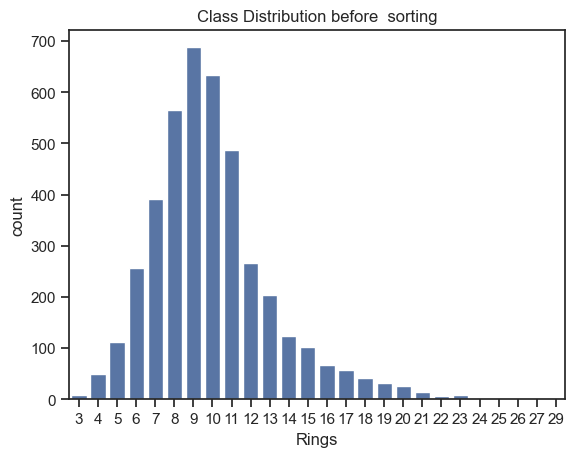

,Original_Rings,Binned_Category
520,3,1
44,4,1
42,5,1
48,6,1
1,7,1
5,8,1
2,9,2
3,10,3
12,11,4
15,12,4


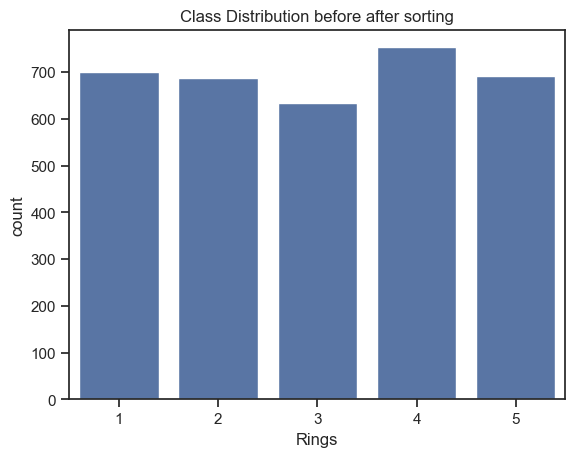

In [113]:
print(f'Data: shape={abalone[D].shape}')
display("describe",abalone[D].describe())
display("skew:",abalone[D].skew())
display("kurtosis", abalone[D].kurtosis())
display("variance", abalone[D].std())

feature_range = abalone[D].max() - abalone[D].min()
display("range:")
display(feature_range)


# sns.histplot(abalone['Height'], bins=30, kde=True)  
# plt.title("Height Feature Distribution")
# plt.show()

Q1 = abalone['Height'].quantile(0.25)
Q3 = abalone['Height'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
abalone = abalone[(abalone['Height'] >= lower_bound) & (abalone['Height'] <= upper_bound)]
print(f'Data: shape after removing outliers={abalone[D].shape}')

# subset = ['Length', 'Diameter', 'Height']
# sns.pairplot(abalone[subset])
# plt.show()

# sns.countplot(x =abalone[C])
# plt.title("Class Distribution")
# plt.show()

#normalize the data
scaler = StandardScaler()
numeric_features = abalone.columns[1:-1]
abalone[numeric_features] = scaler.fit_transform(abalone[numeric_features])

sns.countplot(x = abalone[C])
plt.title("Class Distribution before  sorting")
plt.show()


X = abalone[DL]
y = abalone[C]
#splitting the target variable into buckets to make it a balanced classification problem
value_counts = y.value_counts().sort_index()
cumulative_counts = value_counts.cumsum()
total_samples = cumulative_counts.max()
num_buckets = 5

percentiles = np.linspace(0, 1, num_buckets + 1)  # Create bin edges
bin_edges = np.percentile(y, percentiles * 100) #find boundaries
bin_labels = range(1, num_buckets + 1)

#y_bucket = pd.cut(y, bins=bin_edges, labels=range(1, num_buckets + 1), include_lowest=True)
y_bucket = pd.qcut(y, q=num_buckets, labels=range(1, num_buckets + 1))


ring_to_category = pd.DataFrame({'Original_Rings': y, 'Binned_Category': y_bucket})
ring_to_category = ring_to_category.drop_duplicates().sort_values(by='Original_Rings')
display(ring_to_category)

class_1_subset = X[y_bucket == 1]
class_1_subset_y = y_bucket[y_bucket == 1] 
class_1_indices = y_bucket[y_bucket == 1].index  # Get indices of class 1
other_class_indices = y_bucket[y_bucket != 1].index  # Get indices of other classes
class_1_sampled_indices = np.random.choice(class_1_indices, size=700, replace=False)  # Choose 500 random samples
final_indices = np.concatenate([class_1_sampled_indices, other_class_indices])


# Step 3: Use these indices to select from X and y
X = X.loc[final_indices] 
y = y_bucket.loc[final_indices] 

X, y = shuffle(X, y, random_state=42)

sns.countplot(x=y)
plt.title("Class Distribution before after sorting")
plt.show()


#apply one hot encoding for categorical data
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), L)  # Encode categorical feature
], remainder='passthrough')




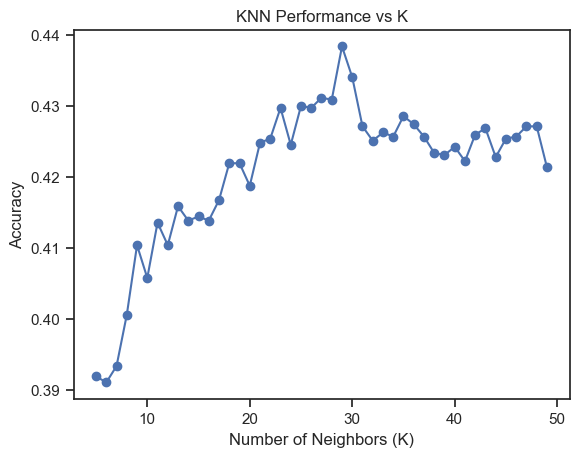

In [ ]:
#KNN classification
k_performance = {}

for k in range(5, 50):
    
    KNN = Pipeline([
    ('preprocessing', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=k, metric='euclidean'))  # Use Euclidean distance
    ])          
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    accuracies = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = KNN
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracies.append(accuracy_score(y_test, y_pred))
        
    k_performance[k] = np.mean(accuracies)

plt.plot(k_performance.keys(), k_performance.values(), marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy') 
plt.title('KNN Accuracy Performance vs K')
plt.show()


In [ ]:
#Decision Tree Classifier

In [ ]:
#Random Forest Classifier

In [ ]:
#Summarize Results